# Tutorial 5: Perturbation Analysis - Phenotype Switching

In-silico perturbation experiments predict what happens when a TF is knocked down or overexpressed. For the MM_lines melanoma dataset, we'll use this to simulate **phenotype switching** - the transition between melanocytic (MEL) and mesenchymal (MES) states.

## Phenotype Switching in Melanoma

Phenotype switching is a key driver of metastasis and therapy resistance in melanoma.
The SCENIC+ paper showed that knocking down key TFs can induce these transitions:

| Perturbation | Expected Effect |
|--------------|-----------------|  
| **SOX10 KD** | MEL→MES shift (loss of melanocytic identity) |
| **ZEB1 KD** | MES→MEL shift (loss of mesenchymal identity) |

We'll validate this using deepSCENIC's perturbation simulation.

## Setup

In [1]:
import torch

import deepscenic as ds

print(f"deepSCENIC version: {ds.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

deepSCENIC version: 0.1.0
Using device: cuda


## Load Model and Data

In [2]:
data_dir = "data/MM_lines_results/"

# Load trained model and data
model = ds.tl.load_model(data_dir + "checkpoints/deepscenic_model.pt", device=device)
mdata = ds.read(data_dir + "preprocessed_data.h5mu")

print(f"Model: {len(model.tf_names)} TFs")

/home/VIB.LOCAL/lukas.mahieu/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/groups/vib.ai/stein.aerts/lmahieu/software/miniconda3/envs/deepscenic-dev/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
deepscenic.tl - INFO - Loaded model from data/MM_lines_results/checkpoints/deepscenic_model.pt: 12156 genes, 1462 TFs, 281820 regions
deepscenic.io - INFO - Loaded data/MM_lines_results/preprocessed_data.h5mu: 936 cells, 12156 genes, 281820 regions


Model: 1462 TFs


In [3]:
# Define marker genes for tracking phenotype changes
MEL_MARKERS = ["MITF", "DCT", "TYR", "PMEL"]  # Melanocytic markers
MES_MARKERS = ["JUN", "ZEB1", "NFIB"]   # Mesenchymal markers

print(f"MEL markers: {MEL_MARKERS}")
print(f"MES markers: {MES_MARKERS}")

MEL markers: ['MITF', 'DCT', 'TYR', 'PMEL']
MES markers: ['JUN', 'ZEB1', 'NFIB']


## SOX10 Knockdown: Proof-of-Principle for MEL→MES Transition

SOX10 is a master regulator of the melanocytic lineage. Knocking it down should cause:
1. **Downregulation of MEL markers**
2. **Upregulation of MES markers**: As cells lose melanocytic identity
3. **Shift toward MES state**: Cells should move toward mesenchymal phenotype

Let's simulate this and verify the expected biology.

In [4]:
# Simulate SOX10 knockdown with intermediate results for convergence analysis
logFC_trace = ds.tl.simulate_perturbation(
    model,
    mdata,
    tf_name="SOX10",
    level=0,  # Complete knockdown
    n_iter=10,
    return_intermediate=True,  # Get logFC at each iteration
)

# Get final logFC for downstream analysis
logFC_final = logFC_trace[10]

print(f"Simulated SOX10 knockdown across {logFC_final.shape[0]} cells")
print(f"Tracking effects on {logFC_final.shape[1]} genes over 10 iterations")

Simulating perturbation: 100%|██████████| 4/4 [00:04<00:00,  1.01s/it]

Simulated SOX10 knockdown across 936 cells
Tracking effects on 12156 genes over 10 iterations


## Iteration Convergence: How Effects Propagate

The perturbation simulation runs iteratively to capture indirect effects through TF-TF regulatory cascades. Let's visualize how marker gene expression changes across iterations:

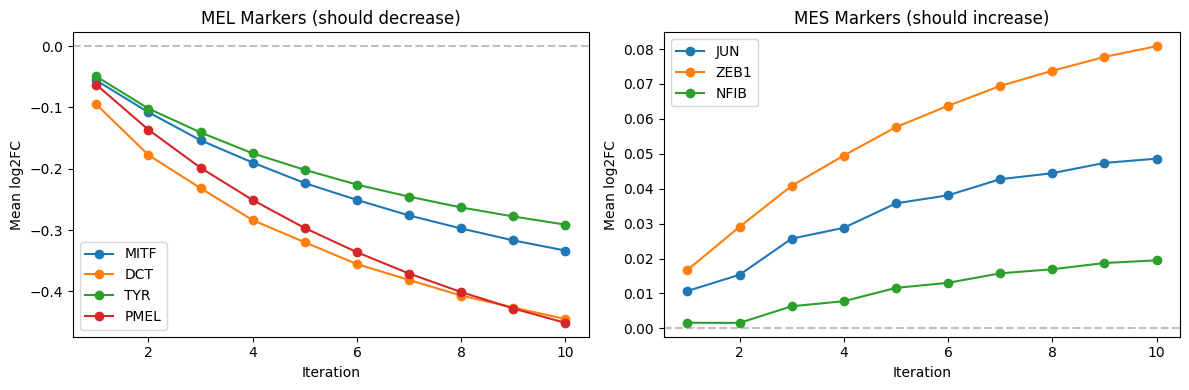

In [5]:
import matplotlib.pyplot as plt

# Get gene indices for markers
gene_names = list(mdata.mod["rna"].var_names)

def get_gene_indices(markers, gene_names):
    """Get indices of marker genes that exist in the dataset."""
    indices = {}
    for m in markers:
        if m in gene_names:
            indices[m] = gene_names.index(m)
    return indices

mel_idx = get_gene_indices(MEL_MARKERS, gene_names)
mes_idx = get_gene_indices(MES_MARKERS, gene_names)

# Extract mean logFC per iteration for each marker
iterations = sorted(logFC_trace.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MEL markers
for marker, idx in mel_idx.items():
    logfc_per_iter = [logFC_trace[i][:, idx].mean() for i in iterations]
    axes[0].plot(iterations, logfc_per_iter, 'o-', label=marker)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Mean log2FC")
axes[0].set_title("MEL Markers (should decrease)")
axes[0].legend()

# MES markers
for marker, idx in mes_idx.items():
    logfc_per_iter = [logFC_trace[i][:, idx].mean() for i in iterations]
    axes[1].plot(iterations, logfc_per_iter, 'o-', label=marker)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Mean log2FC")
axes[1].set_title("MES Markers (should increase)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Co-Embedding: Visualizing Phenotype Shift

To visualize how cells shift in phenotype space, we can project both original and perturbed expression profiles into the same embedding using {func}`~deepscenic.pl.perturbation_coembedding`. This shows the direction and magnitude of the phenotype transition.

Extracting embeddings: 100%|██████████| 15/15 [00:02<00:00,  6.66it/s]


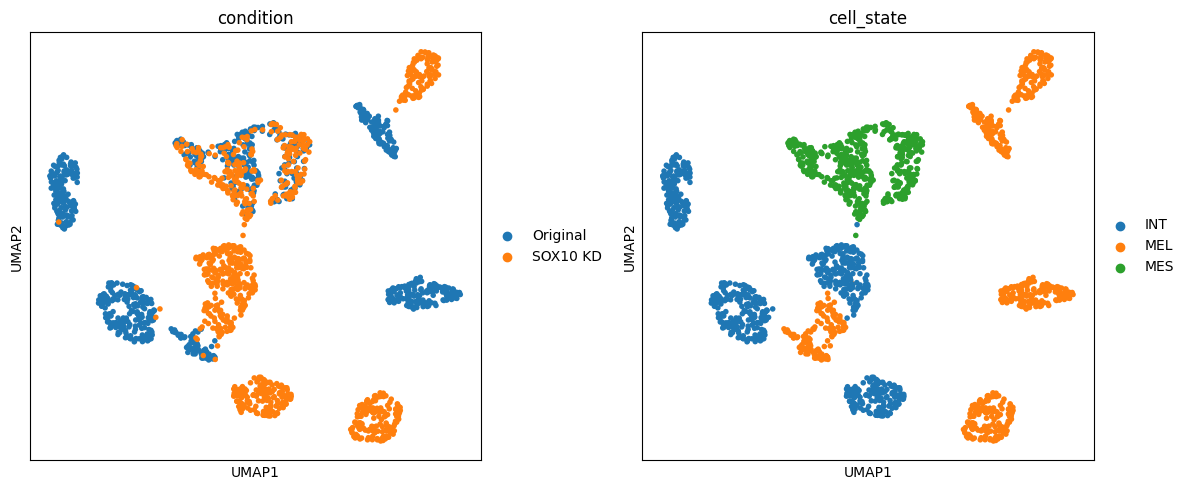

In [6]:
# Get original expression (for comparison)
# We'll use predicted gene signal (z_rna) as the basis for embedding
ds.tl.to_latent(model, mdata, batch_size=64)
original_expr = mdata.obsm["X_deepscenic_z_rna"]

# Compute perturbed z_rna using logFC
perturbed_expr = original_expr + logFC_final

# Visualize co-embedding of original and perturbed expression
ds.pl.perturbation_coembedding(
    original_expr,
    perturbed_expr,
    obs=mdata.obs,
    color=["condition", "cell_state"],
    condition_labels=["Original", "SOX10 KD"],
)

### Interpreting the Co-Embedding

In the co-embedding plot:

- **Original cells** (left plot, blue): Your baseline cell distribution
- **Perturbed cells** (left plot, orange): Where cells move after SOX10 KD
- **Direction of shift**: If SOX10 KD causes MEL→MES transition, MEL cells should shift toward the MES region

Look for:
1. **MEL cells shifting toward MES territory** - confirms the expected phenotype switch
2. **MES cells showing minimal shift** - they're already in the mesenchymal state
3. **INT cells showing intermediate response** - they're the most plastic

## Visualize Perturbation Effects

### Volcano Plot

Volcano plots show effect size vs significance:

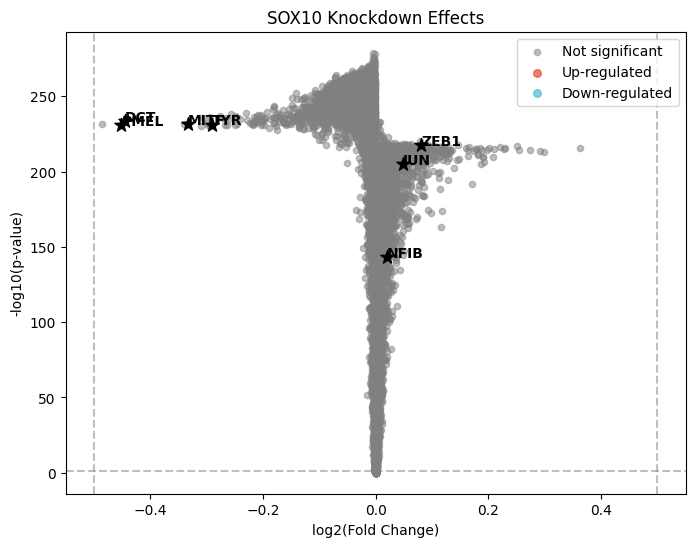

In [7]:
# Process results for plotting
results = ds.tl.process_perturbation_results(logFC_final, mdata, tf_name="SOX10")

# Volcano plot shows effect size vs significance
ds.pl.volcano_perturbation(
    results,
    highlight_genes=MEL_MARKERS + MES_MARKERS,
    title="SOX10 Knockdown Effects"
)

```{tip}
**Expected results for SOX10 knockdown:**

1. **MEL markers down**: MITF, DCT, TYR should have negative log2FC (red in volcano, downregulated)
2. **MES markers up**: JUN, VIM, ZEB1 should have positive log2FC (blue in volcano, upregulated)
3. **Indirect targets**: Genes regulated by MITF (a SOX10 target) will also change
4. **Self-downregulation**: SOX10 itself should show strong downregulation (confirming the perturbation)

If you see the opposite pattern, check:
- Model training convergence (Tutorial 3)
- GRN quality (Tutorial 4) - does SOX10 have MITF as a target?
```

### Heatmap

Heatmap of top affected genes:

/home/VIB.LOCAL/lukas.mahieu/.local/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


ValueError: The number of observations cannot be determined on an empty distance matrix.

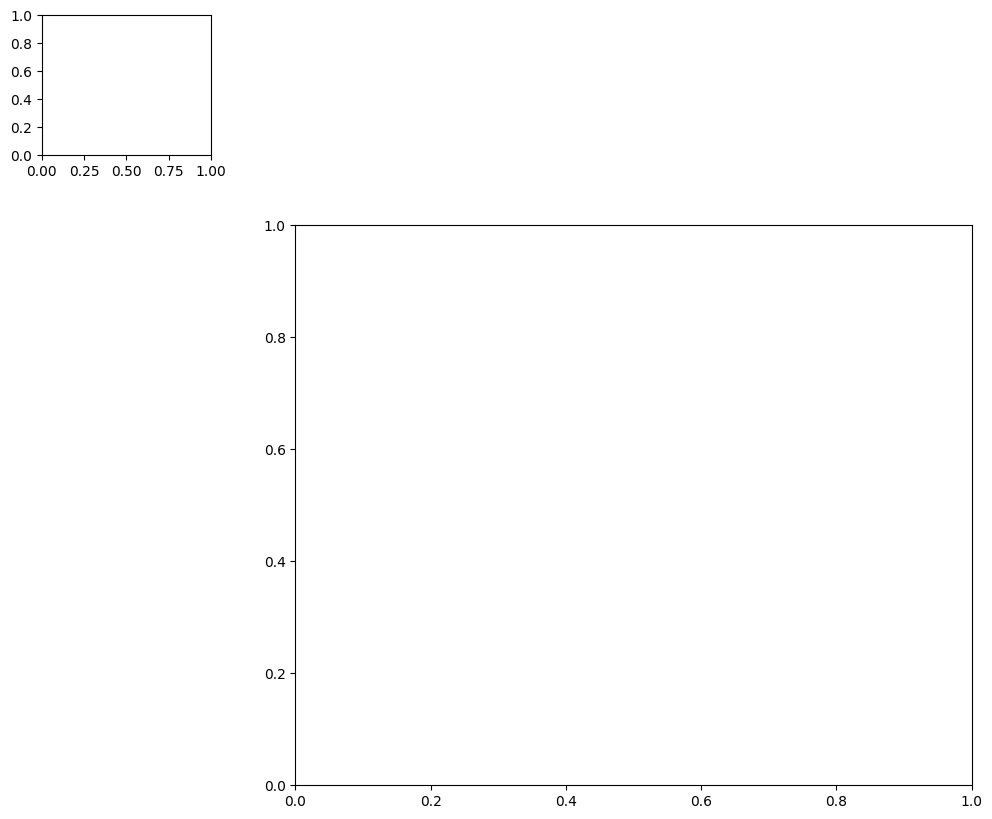

In [8]:
# Heatmap of top affected genes
ds.pl.heatmap_perturbation(results, top_n=30)

### Dotplot by Cell Type

Dotplot showing effects by cell type (size = magnitude, color = direction):

In [ ]:
# Dotplot by cell type (if cell annotations available)
ds.pl.dotplot_perturbation(
    results,
    mdata=mdata,
    groupby="cell_state",
    genes=["MITF", "DCT", "TYR", "SOX10"],
)

TypeError: dotplot_perturbation() got an unexpected keyword argument 'groupby'

## ZEB1 Knockdown: Reverse Phenotype Switch (MES→MEL)

To validate our GRN, let's simulate the reverse transition. ZEB1 is a mesenchymal TF - knocking it down should cause MES cells to shift toward MEL.

Simulating perturbation: 100%|██████████| 4/4 [00:03<00:00,  1.11it/s]


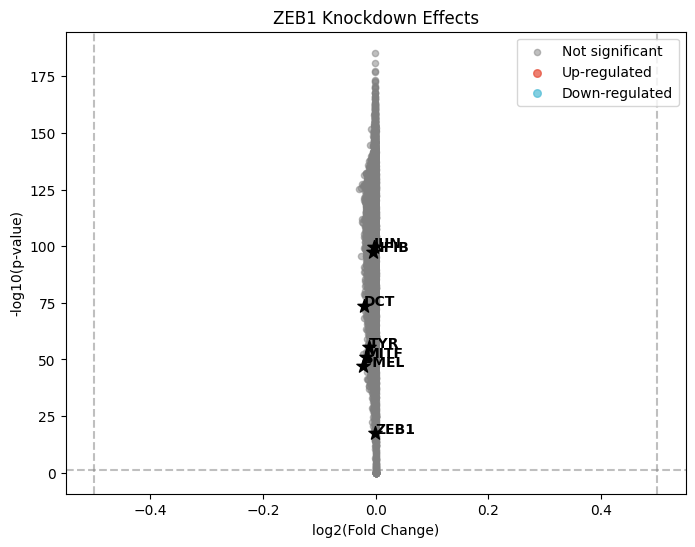

In [11]:
# Simulate ZEB1 knockdown
logFC_zeb1 = ds.tl.simulate_perturbation(
    model,
    mdata,
    tf_name="ZEB1",
    level=0,
    n_iter=10,
)

results_zeb1 = ds.tl.process_perturbation_results(logFC_zeb1, mdata, tf_name="ZEB1")

# Volcano plot for ZEB1 KD
ds.pl.volcano_perturbation(
    results_zeb1,
    highlight_genes=MEL_MARKERS + MES_MARKERS,
    title="ZEB1 Knockdown Effects"
)

### Expected Results for ZEB1 KD

For the reverse transition (MES→MEL):
- **MEL markers should increase** (positive log2FC)
- **MES markers should decrease** (negative log2FC)

This bidirectional validation confirms that the GRN captures the regulatory logic of phenotype switching.

## Multi-TF Perturbation

Simulate perturbation of multiple TFs simultaneously:

In [12]:
# Simulate combined knockdown of two TFs
logFC_multi = ds.tl.simulate_multi_perturbation(
    model,
    mdata,
    tf_names=["SOX10", "MITF"],
    levels=[0, 0],  # Both knocked down
)

results_multi = ds.tl.process_perturbation_results(
    logFC_multi, mdata, tf_name=["SOX10", "MITF"]
)
results_multi.head()

Simulating multi-perturbation: 100%|██████████| 4/4 [00:03<00:00,  1.11it/s]


,gene,tf,log2fc,abs_log2fc,pvalue
0,ABCF2,SOX10+MITF,-0.104850,0.104850,0.000000e+00
1,ABL1,SOX10+MITF,-0.045070,0.045070,1.089268e-270
2,ACAA1,SOX10+MITF,-0.098172,0.098172,1.069439e-292
3,ACO1,SOX10+MITF,0.022721,0.022721,9.882830e-89
4,ADARB1,SOX10+MITF,-0.085098,0.085098,1.131648e-289


## Comparing TF Effects

Compare perturbation effects across multiple TFs:

/home/VIB.LOCAL/lukas.mahieu/.local/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


ValueError: The number of observations cannot be determined on an empty distance matrix.

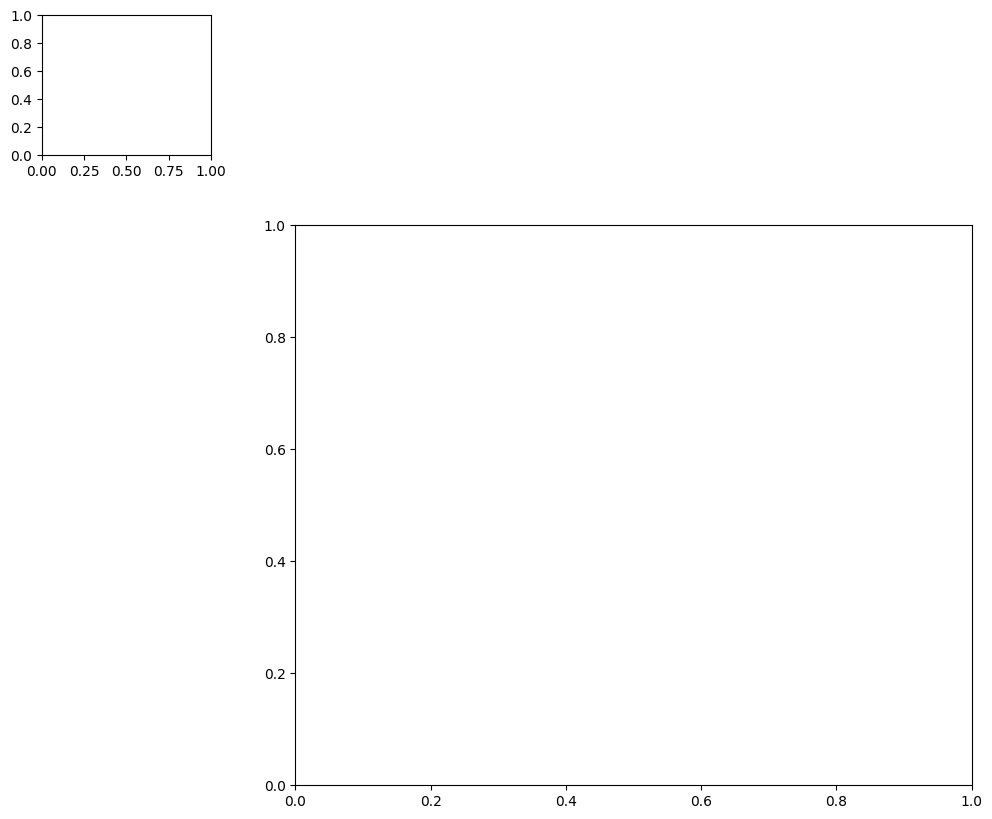

In [13]:
# Heatmap comparing effects of different TF perturbations
ds.pl.heatmap_perturbation(results_multi, top_n=30)

## Next Steps

Now that you've analyzed perturbation effects:

- Explore advanced genomic visualizations: {doc}`06_advanced_visualization`